In [1]:
import torch
import math
import collections
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt

## Data

In [2]:
!wget -O fra-eng.zip http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip
!unzip -o fra-eng.zip -d .

--2026-05-10 17:01:50--  http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 3.163.164.229
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|3.163.164.229|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3420152 (3.3M) [application/zip]
Saving to: ‘fra-eng.zip’

fra-eng.zip         100%[===================>]   3.26M  --.-KB/s    in 0.05s   

2026-05-10 17:01:50 (65.8 MB/s) - ‘fra-eng.zip’ saved [3420152/3420152]

Archive:  fra-eng.zip
  inflating: ./fra-eng/fra.txt       
  inflating: ./fra-eng/_about.txt    


In [3]:
def get_raw_text():
    with open("fra-eng/fra.txt", 'r') as f:
        return f.read()

raw_text = get_raw_text()
# print(raw_text[:80])

In [4]:
def process_text(text):
    text = text.replace('\u202f', ' ').replace('\xa0', ' ')
    no_space = lambda char, prev_char: char in ',.!?"' and prev_char != ' '
    out = [' ' + char if i>0 and no_space(char, text[i-1]) else char for i,char in enumerate(text.lower())]
    return ''.join(out).replace('"', '')

processed_text = process_text(raw_text)
# print(processed_text[:75])

In [5]:
def tokenize(text, max_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if max_examples and i>max_examples: break
        items = line.split('\t')
        if len(items)==2:
            source.append([t for t in f"{items[0]} <eos>".split()])
            target.append([t for t in f"{items[1]} <eos>".split()])
    return source, target
source, target = tokenize(processed_text)
source[:5], target[:5]

([['go', '.', '<eos>'],
  ['hi', '.', '<eos>'],
  ['run', '!', '<eos>'],
  ['run', '!', '<eos>'],
  ['who', '?', '<eos>']],
 [['va', '!', '<eos>'],
  ['salut', '!', '<eos>'],
  ['cours', '!', '<eos>'],
  ['courez', '!', '<eos>'],
  ['qui', '?', '<eos>']])

In [6]:
class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens, (list, tuple)):
            tokens = [t for line in tokens for t in line]
        self.counter = collections.Counter(tokens)
        self.freq_count = sorted(self.counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_tokens = list(sorted(set(["<unk>"] + reserved_tokens + [t for t,f in self.freq_count if f>=min_freq])))
        self.tokens_to_idx = {t:i for i,t in enumerate(self.idx_to_tokens)}

    def __len__(self): return len(self.idx_to_tokens)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.tokens_to_idx.get(tokens, self.unk)
        return [self.__getitem__(t) for t in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices)>1:
            return [self.idx_to_tokens[i] for i in indices]
        return self.idx_to_tokens[indices]

    @property
    def unk(self): return self.tokens_to_idx["<unk>"]

In [7]:
def build_arrays(raw_text, num_steps=7, src_vocab=None, tgt_vocab=None, num_train=None, num_eval=None):
    def build(tokens, vocab, is_tgt):
        pad_or_trim = lambda seq, n_steps: (
            seq[:n_steps] if n_steps<len(seq) else seq + ["<pad>"] * (n_steps - len(seq))
        )
        tokens = [pad_or_trim(seq, num_steps) for seq in tokens]
        if is_tgt:
            tokens = [["<sos>"] + seq for seq in tokens]
        if vocab is None:
            vocab = Vocab(tokens=tokens, min_freq=2, reserved_tokens=["<sos>", "<eos>", "<pad>"])
        array = torch.tensor([vocab[seq] for seq in tokens])
        valid_array = (array != vocab["<pad>"]).type(torch.int64).sum(dim=1)
        return array, vocab, valid_array
    max_examples = num_train + num_eval if (num_train is not None and num_eval is not None) else None
    source, target = tokenize(process_text(raw_text), max_examples)
    src_array, src_vocab, src_valid_len = build(source, src_vocab, False)
    tgt_array, tgt_vocab, _ = build(target, tgt_vocab, True)
    return (
        (src_array, tgt_array[:, :-1], src_valid_len, # inputs
        tgt_array[:, 1:]), # labels
        src_vocab, tgt_vocab
    )

In [8]:
num_train = 512
num_eval = 256
num_steps = 7
arrays, src_vocab, tgt_vocab = build_arrays(get_raw_text(), num_steps=num_steps,
    src_vocab=None, tgt_vocab=None, num_train=num_train, num_eval=num_eval)

In [9]:
def get_dataloader(arrays, shuffle, batch_size):
    indices = slice(0, num_train) if shuffle else slice(num_train, num_train+num_eval)
    arrays = [a[indices] for a in arrays]
    return torch.utils.data.DataLoader(dataset=torch.utils.data.TensorDataset(*arrays),
                                       shuffle=shuffle, batch_size=batch_size)

batch_size = 128
train_dataloader = get_dataloader(arrays, True, batch_size)
eval_dataloader = get_dataloader(arrays, False, batch_size)

## Model

In [10]:
def masked_softmax(x, valid_lens):
    # x: dim 3D | valid_lens: dim 2D or 1D
    def _sequence_mask(x, valid_len, value=0):
        maxlen = x.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=x.device)[None, :] < valid_len[:, None]
        x[~mask] = value
        return x
    if valid_lens is None:
        return F.softmax(x, dim=-1)
    else:
        shape = x.shape
        if valid_lens.dim()==1:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        x = _sequence_mask(x.reshape(-1, shape[-1]), valid_lens, -1e6)
        return F.softmax(x.reshape(shape), dim=-1)


In [11]:
class DotProductAttention(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # queries shape: (batch_size, num_queries, dim_q)
        # keys    shape: (batch_size, num_kv_pairs, dim_k)
        # values  shape: (batch_size, num_kv_pairs, dim_v)
        # dim_q = dim_k
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d) # shape: (batch_size, num_queries, num_kv_pairs)
        self.attention_weights = masked_softmax(scores, valid_lens)     # shape: (batch_size, num_queries, num_kv_pairs)
        return torch.bmm(self.dropout(self.attention_weights), values)  # shape: (batch_size, num_queries, dim_v)

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_hiddens, num_heads, dropout):
        super().__init__()
        self.num_heads = num_heads
        self.W_q = nn.Linear(in_features=num_hiddens, out_features=num_hiddens)
        self.W_k = nn.Linear(in_features=num_hiddens, out_features=num_hiddens)
        self.W_v = nn.Linear(in_features=num_hiddens, out_features=num_hiddens)
        self.W_o = nn.Linear(in_features=num_hiddens, out_features=num_hiddens)
        self.attention = DotProductAttention(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # queries shape: (batch_size, num_queries, dim_q)
        # keys    shape: (batch_size, num_kv_pairs, dim_k)
        # values  shape: (batch_size, num_kv_pairs, dim_v)
        # dim_q = dim_k
        # dim_q = dim_k = dim_v = num_hiddens
        # valid_lens shape: (batch_size,) | (batch_size, num_queries)
        queries = self.transpose_qkv(self.W_q(queries)) # shape: (batch_size*num_heads, num_queries|num_kv_pairs, num_hiddens/num_heads)
        keys    = self.transpose_qkv(self.W_k(keys))    # shape: (batch_size*num_heads, num_kv_pairs, num_hiddens/num_heads)
        values  = self.transpose_qkv(self.W_v(values))  # shape: (batch_size*num_heads, num_kv_pairs, num_hiddens/num_heads)

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0) # shape: (batch_size*num_heads) | (batch_size*num_heads, num_queries)

        output = self.attention(queries, keys, values, valid_lens) # shape: (batch_size*num_heads, num_queries, num_hiddens/num_heads)
        output = self.transpose_output(output)                     # shape: (batch_size, num_queries, num_hiddens)
        return self.W_o(output)                                    # shape: (batch_size, num_queries, num_hiddens)

    def transpose_qkv(self, x):
        # [in practice: num_hiddens = (num_queries|num_kv_pairs) * num_heads]

        # x shape: (batch_size, num_queries|num_kv_pairs, num_hiddens)
        x = x.reshape(x.shape[0], x.shape[1], self.num_heads, -1) # shape: (batch_size, num_queries|num_kv_pairs, num_heads, num_hiddens/num_heads)
        x = x.permute(0, 2, 1, 3)                                 # shape: (batch_size, num_heads, num_queries|num_kv_pairs, num_hiddens/num_heads)
        return x.reshape(-1, x.shape[2], x.shape[3])              # shape: (batch_size*num_heads, num_queries|num_kv_pairs, num_hiddens/num_heads)

    def transpose_output(self, x):
        # x shape: (batch_size*num_heads, num_queries, num_hiddens/num_heads)
        x = x.reshape(-1, self.num_heads, x.shape[1], x.shape[2]) # shape: (batch_size, num_heads, num_queries, num_hiddens/num_heads)
        x = x.permute(0, 2, 1, 3)                                 # shape: (batch_size, num_queries, num_heads, num_hiddens/num_heads)
        return x.reshape(x.shape[0], x.shape[1], -1)              # shape: (batch_size, num_queries, num_hiddens)

In [13]:
num_hiddens = 100
num_heads = 5
mh_attention = MultiHeadAttention(num_hiddens=num_hiddens, num_heads=num_heads, dropout=0.2)
batch_size = 2
num_queries = 4
num_kv_pairs = 6
valid_lens = torch.tensor([3, 2])
queries = torch.randn((batch_size, num_queries, num_hiddens))
keys = torch.randn((batch_size, num_kv_pairs, num_hiddens))
values = torch.randn((batch_size, num_kv_pairs, num_hiddens))
out = mh_attention(queries, keys, values, valid_lens)
queries.shape, keys.shape, values.shape, out.shape, mh_attention.attention.attention_weights.shape

(torch.Size([2, 4, 100]),
 torch.Size([2, 6, 100]),
 torch.Size([2, 6, 100]),
 torch.Size([2, 4, 100]),
 torch.Size([10, 4, 6]))

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=100):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        x = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1) / torch.pow(10000, torch.arange(0,num_hiddens,2,dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(x)
        self.P[:, :, 1::2] = torch.cos(x)

    def forward(self, x):
        x = x + self.P[:, :x.shape[1], :].to(x.device)
        return self.dropout(x)

torch.Size([1, 60, 32]) torch.Size([1, 60, 32]) torch.Size([1, 100, 32])


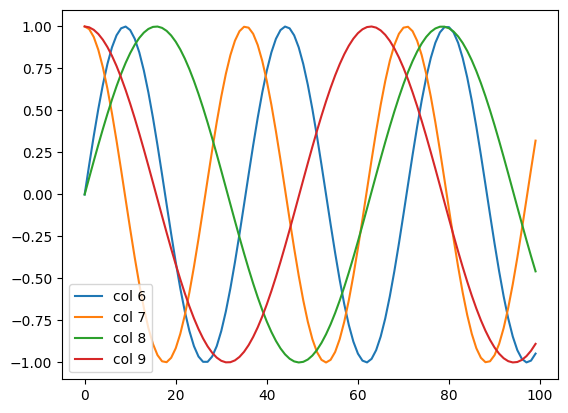

In [15]:
encoding_dim = 32
num_steps = 60
pos_encoding = PositionalEncoding(num_hiddens=encoding_dim, dropout=0)

x = torch.rand((1, num_steps, encoding_dim))
y = pos_encoding(x)
print(x.shape, y.shape, pos_encoding.P.shape)
for i in range(6,10):
    plt.plot(pos_encoding.P[0, :, i], label=f"col {i}")
    plt.legend()
plt.show()

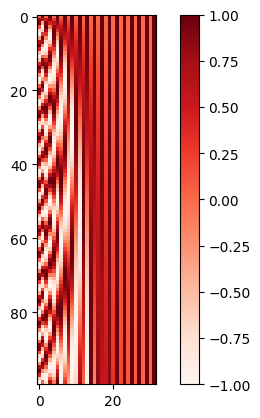

In [16]:
plt.imshow(pos_encoding.P[0], cmap="Reds")
plt.colorbar(); plt.show()

In [17]:
class Encoder(nn.Module):
    def __init__(self, ):
        super(Encoder, self).__init__()

    def forward(self, x, *args):
        raise NotImplemented


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

    def init_state(self, enc_all_outputs, enc_valid_lens, *args):
        raise NotImplemented

    def forward(self, x, state):
        raise NotImplemented

class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_x, dec_x, enc_valid_lens, *args):
        enc_all_outputs = self.encoder(enc_x, enc_valid_lens)
        dec_state = self.decoder.init_state(enc_all_outputs, enc_valid_lens, *args)
        dec_outputs = self.decoder(dec_x, dec_state)
        return dec_outputs

In [18]:
class PositionWiseFeedForwardNetwork(nn.Module):
    def __init__(self, ffn_num_hiddens, ffn_num_inputs, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.Linear(in_features=ffn_num_inputs, out_features=ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(in_features=ffn_num_hiddens, out_features=ffn_num_outputs)

    def forward(self, x):
        return self.dense2(self.relu(self.dense1(x)))

In [19]:
class AddNorm(nn.Module):
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(norm_shape)

    def forward(self, x, y):
        return self.layer_norm(x + self.dropout(y))

In [20]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, num_hiddens, num_heads, ffn_num_inputs, ffn_num_hiddens, dropout):
        super().__init__()
        self.mha = MultiHeadAttention(num_hiddens=num_hiddens, num_heads=num_heads, dropout=dropout)
        self.add_norm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFeedForwardNetwork(ffn_num_hiddens=ffn_num_hiddens, ffn_num_inputs=ffn_num_inputs, ffn_num_outputs=num_hiddens)
        self.add_norm2 = AddNorm(num_hiddens, dropout)

    def forward(self, x, valid_lens):
        out = self.add_norm1(x, self.mha(x, x, x, valid_lens))
        return self.add_norm1(out, self.ffn(out))

In [21]:
class TransformerEncoder(Encoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blocks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens=num_hiddens, dropout=dropout, max_len=100)
        self.blocks = nn.Sequential()
        for i in range(num_blocks):
            self.blocks.add_module(name=f"block_{i}",
                                   module=TransformerEncoderBlock(num_hiddens=num_hiddens, num_heads=num_heads,ffn_num_inputs=num_hiddens,
                                                                  ffn_num_hiddens=ffn_num_hiddens, dropout=dropout))
    def forward(self, x, valid_lens):
        # pos enc values are between -1 and 1 -> rescale
        x = self.pos_encoding(self.embedding(x) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blocks)
        for i, blk in enumerate(self.blocks):
            x = blk(x, valid_lens)
            self.attention_weights[i] = blk.mha.attention.attention_weights
        return x

In [22]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
encoder(torch.ones((2,100), dtype=torch.long), None).shape

torch.Size([2, 100, 24])

In [23]:
class TransformerDecoderBlock(nn.Module):
    # i-th block in the Transformer decoder
    def __init__(self, num_hiddens, num_heads, ffn_num_inputs, ffn_num_hiddens, dropout, i):
        super().__init__()
        self.i = i
        self.masked_mha = MultiHeadAttention(num_hiddens=num_hiddens, num_heads=num_heads, dropout=dropout)
        self.add_norm1 = AddNorm(norm_shape=num_hiddens, dropout=dropout)
        self.cross_mha = MultiHeadAttention(num_hiddens=num_hiddens, num_heads=num_heads, dropout=dropout)
        self.add_norm2 = AddNorm(norm_shape=num_hiddens, dropout=dropout)
        self.ffn = PositionWiseFeedForwardNetwork(ffn_num_hiddens=ffn_num_hiddens, ffn_num_inputs=ffn_num_inputs, ffn_num_outputs=num_hiddens)
        self.add_norm3 = AddNorm(norm_shape=num_hiddens, dropout=dropout)

    def forward(self, x, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # state[2][self.i] contains the representations of the decoded output at the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = x
        else:
            key_values = torch.cat((state[2][self.i], x), dim=1)
        state[2][self.i]  = key_values
        if self.training:
            batch_size, num_steps, _ = x.shape
            # shape of dec_valid_lens: (batch_size, num_steps), where every
            # row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(1, num_steps+1, device=x.device).repeat(batch_size, 1)
        else: dec_valid_lens = None

        # self-attention
        x2 = self.masked_mha(x, key_values, key_values, dec_valid_lens)
        y = self.add_norm1(x, x2)
        # encoder-decoder attention
        # enc_outputs shape: (batch_size, num_steps, num_hiddens)
        y2 = self.cross_mha(y, enc_outputs, enc_outputs, enc_valid_lens)
        z = self.add_norm2(y, y2)
        return self.add_norm3(z, self.ffn(z)), state

In [24]:
class TransformerDecoder(Decoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads, num_blocks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blocks = num_blocks

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens=num_hiddens, dropout=dropout)
        self.blocks = nn.Sequential()
        for i in range(num_blocks):
            self.blocks.add_module(name=f"block_{i}",
                                   module=TransformerDecoderBlock(num_hiddens=num_hiddens, num_heads=num_heads, ffn_num_hiddens=ffn_num_hiddens,
                                                                  ffn_num_inputs=num_hiddens, dropout=dropout, i=i))
        self.dense = nn.Linear(in_features=num_hiddens, out_features=vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None]*self.num_blocks]

    def forward(self, x, state):
        x = self.pos_encoding(self.embedding(x) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blocks) for _ in range(2)]
        for i, blk in enumerate(self.blocks):
            x, state = blk(x, state)
            self._attention_weights[0][i] = blk.masked_mha.attention.attention_weights
            self._attention_weights[1][i] = blk.cross_mha.attention.attention_weights
        return self.dense(x), state

    @property
    def attention_weights(self): return self._attention_weights

In [25]:
class Seq2Seq(EncoderDecoder):
    def __init__(self, encoder, decoder, tgt_pad):
        super(Seq2Seq, self).__init__(encoder, decoder)
        self.tgt_pad = tgt_pad

In [26]:
# def grad_clip(clip_val, model):
#     params = [p for p in model.parameters() if p.requires_grad]
#     for p in model.parameters():
#         if p is None: print(p)
#     norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
#     if norm > clip_val:
#         for p in params:
#             p.grad[:] *= clip_val / norm

In [27]:
def train_transformers(model, max_epochs, clip_val, lr, train_dataloader, eval_dataloader, report_every):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    metrics = {"train_loss": [], "train_acc": [], "eval_loss": [], "eval_acc": []}
    criterion = nn.CrossEntropyLoss(reduction="none")

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr)

    for epoch in range(max_epochs):
        model.train()
        num_instances = 0
        epoch_loss = 0.
        epoch_acc = 0.
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            logits, _ = model(*batch[:-1])
            logits = logits.reshape(-1, logits.shape[-1])
            labels = batch[-1].reshape(-1,)
            loss = criterion(logits, labels)
            mask = (labels != model.tgt_pad).type(torch.float32)
            loss = (loss*mask).sum() / mask.sum()
            loss.backward()
            # grad_clip(clip_val, model)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_val)
            optimizer.step()
            epoch_loss += loss.item() * bs
            epoch_acc += (torch.softmax(logits, dim=-1).argmax(dim=-1)==labels).type(torch.float32).mean().item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_acc /= num_instances
        metrics["train_loss"].append(epoch_loss)
        metrics["train_acc"].append(epoch_acc)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] train_loss: {epoch_loss:.5f}, train_acc: {epoch_acc:.5f}")

        model.eval()
        num_instances = 0
        epoch_loss = 0.
        epoch_acc = 0.
        for step, batch in enumerate(eval_dataloader):
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            with torch.no_grad():
                logits, _ = model(*batch[:-1])
                logits = logits.reshape(-1, logits.shape[-1])
                labels = batch[-1].reshape(-1,)
                loss = criterion(logits, labels)
                mask = (labels != model.tgt_pad).type(torch.float32)
                loss *= mask
                loss = (loss*mask).sum() / mask.sum()
                epoch_loss += loss.item() * bs
                epoch_acc += (torch.softmax(logits, dim=-1).argmax(dim=-1)==labels).type(torch.float32).mean().item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_acc /= num_instances
        metrics["eval_loss"].append(epoch_loss)
        metrics["eval_acc"].append(epoch_acc)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] eval_loss: {epoch_loss:.5f}, eval_acc: {epoch_acc:.5f}")

    return metrics


In [28]:
num_hiddens = 256
num_blocks = 2
dropout = 0.2
ffn_num_hiddens = 64
num_heads = 4
encoder = TransformerEncoder(len(src_vocab), num_hiddens=num_hiddens, ffn_num_hiddens=ffn_num_hiddens, num_heads=num_heads, num_blocks=num_blocks, dropout=dropout)
decoder = TransformerDecoder(len(tgt_vocab), num_hiddens=num_hiddens, ffn_num_hiddens=ffn_num_hiddens, num_heads=num_heads, num_blocks=num_blocks, dropout=dropout)
model = Seq2Seq(encoder=encoder, decoder=decoder, tgt_pad=tgt_vocab["<pad>"])

lr = 0.001
max_epochs = 30
clip_val = 1
metrics = train_transformers(model=model, max_epochs=max_epochs, clip_val=clip_val, lr=lr,
                                     train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)

[0/30] train_loss: 4.29702, train_acc: 0.13839
[0/30] eval_loss: 3.40674, eval_acc: 0.23940
[10/30] train_loss: 1.20588, train_acc: 0.42132
[10/30] eval_loss: 2.65647, eval_acc: 0.36217
[20/30] train_loss: 0.56450, train_acc: 0.49163
[20/30] eval_loss: 2.85955, eval_acc: 0.36886


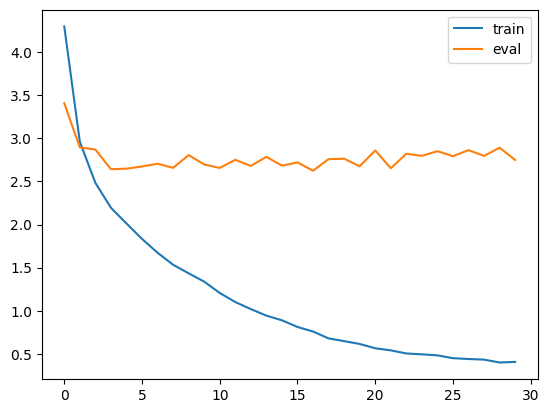

In [29]:
plt.plot(metrics["train_loss"], label="train")
plt.plot(metrics["eval_loss"], label="eval")
plt.legend(); plt.show()

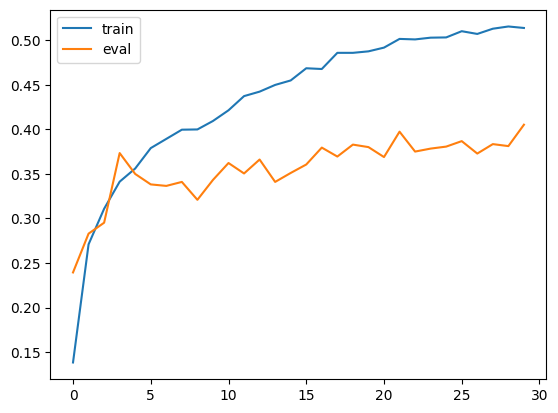

In [30]:
plt.plot(metrics["train_acc"], label="train")
plt.plot(metrics["eval_acc"], label="eval")
plt.legend(); plt.show()

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def greedy_search(batch, model, device, num_steps):
    model.eval()
    with torch.no_grad():
        batch = [a.to(device) for a in batch]
        src, tgt, src_valid_len, _ = batch
        enc_all_outputs = model.encoder(src, src_valid_len).detach()
        dec_state = model.decoder.init_state(enc_all_outputs, src_valid_len)
        outputs = [tgt[:, (0)].unsqueeze(1), ]
        for _ in range(num_steps):
            out, dec_state = model.decoder(outputs[-1], dec_state)
            outputs.append(out.argmax(dim=2))

        return torch.cat(outputs[1:], 1).detach().cpu().numpy()

In [32]:
def bleu_score(pred_seq, true_seq, k):
    pred_tokens, true_tokens = map(lambda x: x.split(' '), (pred_seq, true_seq))
    len_pred = len(pred_tokens)
    len_true = len(true_tokens)
    score = math.exp(min(0, 1-len_true/len_pred))
    for n in range(1, min(k, len_pred)+1):
        num_matches = 0
        label_subs = collections.defaultdict(int)
        for i in range(len_true - n + 1):
            label_subs[' '.join(true_tokens[i:i+n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i:i+n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i:i+n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [33]:
eng_sentences = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fra_sentences = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
raw_text = '\n'.join([src + '\t' + tgt for src, tgt in zip(eng_sentences, fra_sentences)])
test_arrays, _, _ = build_arrays(raw_text, src_vocab=src_vocab, tgt_vocab=tgt_vocab)

In [35]:
preds = greedy_search(test_arrays, model, device, 15)
for en, fr, p in zip(eng_sentences, fra_sentences, preds):
    translation = []
    for token in tgt_vocab.to_tokens(p):
        if token=="" or token=="<eos>":
            break
        translation.append(token)
    translation = ' '.join(translation)
    bleu = bleu_score(translation, fr, k=2)
    print(f"english= {en.ljust(15)} -- translated to={translation.ljust(30)} -- label={fr.ljust(20)} -- bleu_score: {bleu:.5f}")

english= go .            -- translated to=va !                           -- label=va !                 -- bleu_score: 1.00000
english= i lost .        -- translated to=j'ai perdu .                   -- label=j'ai perdu .         -- bleu_score: 1.00000
english= he's calm .     -- translated to=il est mouillé .               -- label=il est calme .       -- bleu_score: 0.65804
english= i'm home .      -- translated to=je suis chez moi .             -- label=je suis chez moi .   -- bleu_score: 1.00000
